## Demo embedding extraction

This notebook shows how to use the embedding extraction module for generating numerical representation using the pre-trained models.

The following family of pre-trained models is available for testing

- Prot5Based
- ESMBasedEmbedding
- Ankh2BasedEmbedding
- BertBasedMebedding
- MistralBasedEmbedding

In [18]:
import warnings
warnings.filterwarnings("ignore")

In [19]:
import sys
sys.path.insert(0, "../../utils/")

In [20]:
import pandas as pd

- Loading modules

In [21]:
from embedding_extraction.prot5_based import Prot5Based
from embedding_extraction.esm_based import ESMBasedEmbedding
from embedding_extraction.bert_based import BertBasedMebedding
from embedding_extraction.mistral_based import MistralBasedEmbedding
from dimensionality_reductions.non_linear_reductions import NonLinearReductions

In [22]:
import seaborn as sns

- Read AMP dataset and select only 10 examples

In [23]:
name_data = "excluded_homology"
#df_data = pd.read_csv(f"../../data/{name_data}.csv")
df_data= pd.read_csv(f"../../models/data/{name_data}.csv")
df_data.head(5)

,sequence,experimental_characteristics,half_life_seconds,length_sequence,target
0,AAHLIDALYAEFLGGRVLTT,Mammalian,15840.0,20,1
1,ADLEVVAATHVLVA,Mammalian,15840.0,14,1
2,ADLEVVAATYV,Mammalian,15840.0,11,1
3,ADLEVVAATYVDDD,Mammalian,15840.0,14,1
4,ADLEVVAATYVDVA,Mammalian,15840.0,14,1


In [24]:
df_data.drop(columns=["length_sequence"], inplace=True)
df_data

,sequence,experimental_characteristics,half_life_seconds,target
0,AAHLIDALYAEFLGGRVLTT,Mammalian,15840.0,1
1,ADLEVVAATHVLVA,Mammalian,15840.0,1
2,ADLEVVAATYV,Mammalian,15840.0,1
3,ADLEVVAATYVDDD,Mammalian,15840.0,1
4,ADLEVVAATYVDVA,Mammalian,15840.0,1
...,...,...,...,...
611,YTSLIHSLIEEWQNQQEKNEQELLELDKWASLWNWF,Yeast,36000.0,2
612,YTSLIHSLIEEWQNQQEKNEQELLELDKWASLWNWF,E_coli,7200.0,0
613,YTSLIHSLIEEYQNQQEKNEQELLELDKWASLWNWF,E_coli,7200.0,0
614,YTSLIHSLIEEYQNQQEKNEQELLELDKWASLWNWF,Mammalian,10080.0,1


### ProT5 evaluation

In [25]:
df_to_prot5 = df_data.copy()
df_to_prot5["sequence"] = df_to_prot5["sequence"].apply(lambda x: " ".join(x)) # this process is necessary for the application of the pre-trained model

prot5_based = Prot5Based(
    name_device="cuda",
    dataset=df_to_prot5,
    name_model="Rostlab/ProstT5",
    name_tokenizer="Rostlab/ProstT5",
    column_seq="sequence",
    columns_ignore=["target","experimental_characteristics"],
)

print("Loading model/tokenizer")
prot5_based.load_model_tokenizer()

print("Generating embedding")
df_embedding = prot5_based.embedding_process(batch_size=5)
df_embedding.to_csv(f"../../data/{name_data}_prot5_embedding.csv", index=False)
prot5_based.cleaning_memory()
print("Process finished")

df_embedding

Using device:  cuda
Loading model/tokenizer
Generating embedding


[+] Embedding: 100%|██████████| 124/124 [00:06<00:00, 17.79batch/s]


Empty cache memory
Process finished


,p_1,p_2,p_3,p_4,p_5,p_6,p_7,p_8,p_9,p_10,...,p_1017,p_1018,p_1019,p_1020,p_1021,p_1022,p_1023,p_1024,target,experimental_characteristics
0,-0.074034,0.163285,-0.014622,-0.029866,-0.047560,0.013300,-0.088256,0.128909,-0.033873,-0.002092,...,-0.007412,0.059608,0.101264,0.092915,0.063616,-0.041226,0.081952,-0.023624,1,Mammalian
1,0.015604,0.044963,-0.048809,0.025770,-0.092541,-0.095458,0.028212,0.077917,-0.120714,0.020894,...,0.023905,-0.129043,-0.023887,0.023630,0.185604,0.060278,0.064172,-0.112706,1,Mammalian
2,0.092940,0.021201,-0.165158,-0.099402,-0.043208,-0.076417,0.002151,0.061563,0.004792,-0.011067,...,0.118462,-0.019016,0.038908,0.049611,0.113538,-0.012867,0.099462,-0.017050,1,Mammalian
3,0.008431,0.157548,-0.126626,-0.099544,0.003998,-0.127813,-0.021769,0.080352,-0.107771,0.085177,...,0.154889,-0.055445,0.109695,0.040922,0.027480,0.007032,0.057281,-0.013059,1,Mammalian
4,-0.016326,0.038181,-0.067546,0.000414,-0.010721,-0.145173,0.096517,0.103734,-0.091483,0.015130,...,0.023580,-0.119006,0.046005,0.028809,0.193336,0.113107,0.092861,-0.050813,1,Mammalian
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
611,-0.053905,-0.063612,-0.002824,0.035457,-0.015660,-0.012405,-0.154817,0.013155,0.044125,0.069480,...,0.021521,-0.007888,0.010999,0.022205,0.086454,-0.147234,0.102648,-0.164371,2,Yeast
612,-0.053905,-0.063612,-0.002824,0.035457,-0.015660,-0.012405,-0.154817,0.013155,0.044125,0.069480,...,0.021521,-0.007888,0.010999,0.022205,0.086454,-0.147234,0.102648,-0.164371,0,E_coli
613,-0.090614,-0.045068,-0.021552,-0.002937,0.022050,0.022217,-0.189644,0.028775,0.052385,0.050269,...,-0.010726,0.023199,0.013153,0.034513,0.122567,-0.112970,0.110353,-0.179618,0,E_coli
614,-0.090614,-0.045068,-0.021552,-0.002937,0.022050,0.022217,-0.189644,0.028775,0.052385,0.050269,...,-0.010726,0.023199,0.013153,0.034513,0.122567,-0.112970,0.110353,-0.179618,1,Mammalian


<Axes: xlabel='p_1', ylabel='p_2'>

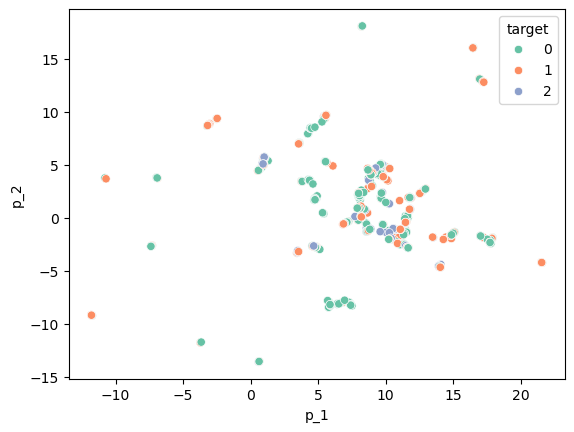

In [26]:
df_values = df_embedding.drop(columns=["target", "experimental_characteristics"])
nonlinear_instance = NonLinearReductions(dataset=df_values)

transform_values_umap = nonlinear_instance.applyUMAP()
transform_values_umap["target"] = df_embedding["target"].values

sns.scatterplot(data=transform_values_umap, x="p_1", y="p_2", hue="target", palette="Set2")


### ESM evaluation

In [27]:
esm_based = ESMBasedEmbedding(
    name_device="cpu",
    dataset=df_data,
    name_model="facebook/esm2_t36_3B_UR50D",
    name_tokenizer="facebook/esm2_t36_3B_UR50D",
    column_seq="sequence",
    columns_ignore=["target", "experimental_characteristics"],
)

print("Loading model/tokenizer")
esm_based.load_model_tokenizer()

print("Generating embedding")
df_embedding = esm_based.embedding_process(batch_size=5)
df_embedding.to_csv(f"../../data/numerical_rep_reg/{name_data}_esm2_t36_3B_UR50D_embedding.csv", index=False)

esm_based.cleaning_memory()
print("Process finished")

df_embedding

Using device:  cpu
Loading model/tokenizer


Loading checkpoint shards: 100%|██████████| 2/2 [00:00<00:00, 13.89it/s]
Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t36_3B_UR50D and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Generating embedding


[+] Embedding: 100%|██████████| 124/124 [03:34<00:00,  1.73s/batch]


Empty cache memory
Process finished


,p_1,p_2,p_3,p_4,p_5,p_6,p_7,p_8,p_9,p_10,...,p_2553,p_2554,p_2555,p_2556,p_2557,p_2558,p_2559,p_2560,target,experimental_characteristics
0,0.035192,-0.077414,0.025200,-0.015292,-0.008537,-0.153772,-0.017255,0.042550,0.003852,0.030939,...,0.043627,-0.035218,0.074590,-0.088036,-0.022450,-0.046315,-0.167538,-0.034106,1,Mammalian
1,0.084531,-0.021626,0.031756,-0.071657,0.008026,-0.138730,-0.004577,0.019358,0.019586,0.014151,...,0.018873,-0.015269,0.059845,-0.080307,0.036988,-0.020019,-0.112207,-0.043393,1,Mammalian
2,0.087514,-0.022981,0.013756,-0.054623,-0.002840,-0.132273,-0.035753,0.009757,-0.000400,0.006263,...,0.029178,-0.028720,0.048489,-0.071656,0.031869,-0.023287,-0.089980,-0.044302,1,Mammalian
3,0.074703,-0.040814,0.024409,-0.073016,-0.006569,-0.177223,-0.060777,0.039241,0.001450,0.025166,...,0.018204,0.002135,0.075026,-0.068083,0.041998,-0.059423,-0.110952,-0.052180,1,Mammalian
4,0.069014,-0.024097,0.012955,-0.066869,-0.001166,-0.176299,-0.030302,0.019652,0.006220,0.026842,...,0.035648,0.003512,0.034738,-0.056687,0.048297,-0.040197,-0.093961,-0.044661,1,Mammalian
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
611,0.042272,-0.030539,0.007767,0.007630,0.027362,-0.034088,-0.048687,0.043724,0.005292,0.010575,...,-0.045808,0.035316,0.010809,-0.041490,-0.019310,-0.029834,-0.108456,-0.000327,2,Yeast
612,0.042272,-0.030539,0.007767,0.007630,0.027362,-0.034088,-0.048687,0.043724,0.005292,0.010575,...,-0.045808,0.035316,0.010809,-0.041490,-0.019310,-0.029834,-0.108456,-0.000327,0,E_coli
613,0.030924,-0.030984,-0.002427,0.008571,0.024386,-0.041594,-0.049353,0.046861,0.013162,0.020851,...,-0.056906,0.028457,0.021312,-0.046623,-0.038150,-0.033509,-0.133304,-0.008305,0,E_coli
614,0.030924,-0.030984,-0.002427,0.008571,0.024386,-0.041594,-0.049353,0.046861,0.013162,0.020851,...,-0.056906,0.028457,0.021312,-0.046623,-0.038150,-0.033509,-0.133304,-0.008305,1,Mammalian


<Axes: xlabel='p_1', ylabel='p_2'>

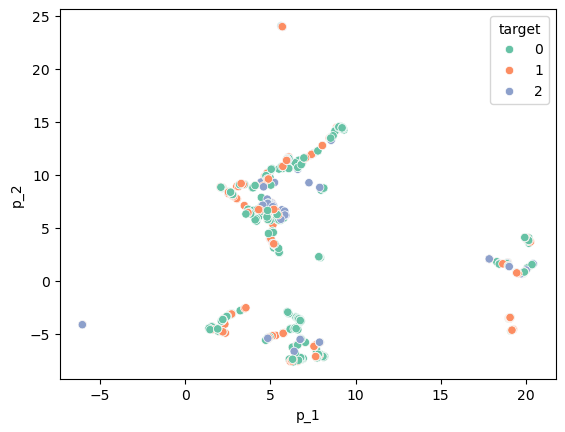

In [28]:
df_values = df_embedding.drop(columns=["target", "experimental_characteristics"])
nonlinear_instance = NonLinearReductions(dataset=df_values)

transform_values_umap = nonlinear_instance.applyUMAP()
transform_values_umap["target"] = df_embedding["target"].values

sns.scatterplot(data=transform_values_umap, x="p_1", y="p_2", hue="target", palette="Set2")


### Bert evaluation

In [29]:
df_to_bert = df_data.copy()
df_to_bert["sequence"] = df_to_bert["sequence"].apply(lambda x: " ".join(x)) # this process is necessary for the application of the pre-trained model

bert_based = BertBasedMebedding(
    name_device="cuda",
    dataset=df_to_bert,
    name_model="Rostlab/prot_bert_bfd_ss3",
    name_tokenizer="Rostlab/prot_bert_bfd_ss3",
    column_seq="sequence",
    columns_ignore=["target", "experimental_characteristics"],
)

print("Loading model/tokenizer")
bert_based.load_model_tokenizer()

print("Generating embedding")
df_embedding = bert_based.embedding_process(batch_size=5)

bert_based.cleaning_memory()
print("Process finished")

df_embedding

Using device:  cuda
Loading model/tokenizer


Some weights of BertModel were not initialized from the model checkpoint at Rostlab/prot_bert_bfd_ss3 and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Generating embedding


[+] Embedding: 100%|██████████| 124/124 [00:02<00:00, 56.25batch/s]

Empty cache memory
Process finished


,p_1,p_2,p_3,p_4,p_5,p_6,p_7,p_8,p_9,p_10,...,p_1017,p_1018,p_1019,p_1020,p_1021,p_1022,p_1023,p_1024,target,experimental_characteristics
0,0.295538,-0.142706,0.059789,-0.010765,0.466893,0.135613,-0.173378,-0.013759,0.081029,0.184358,...,-0.001905,0.035176,0.044793,-0.062239,-0.400736,-0.042597,-0.049345,0.052886,1,Mammalian
1,0.313560,-0.098576,0.062575,-0.066573,0.457607,0.127584,-0.139642,0.028002,0.130054,0.191830,...,0.048493,0.006023,0.081709,-0.092239,-0.413005,-0.044643,-0.024461,0.052101,1,Mammalian
2,0.255821,-0.130391,0.020929,-0.064846,0.498240,0.136958,-0.170319,-0.006167,0.087741,0.200227,...,0.027947,0.034892,0.111467,-0.127107,-0.445189,-0.017226,0.003302,0.069907,1,Mammalian
3,0.230249,-0.167892,0.076838,-0.051028,0.517702,0.147124,-0.187476,0.005356,0.058498,0.225146,...,0.020597,0.053693,0.088621,-0.124345,-0.402064,-0.035642,0.035066,0.054873,1,Mammalian
4,0.281984,-0.104374,0.076851,-0.039850,0.468602,0.141264,-0.162704,0.056895,0.112725,0.241796,...,0.057111,0.007728,0.085793,-0.051521,-0.424471,-0.057000,0.025508,0.075641,1,Mammalian
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
611,0.345540,-0.063798,0.076634,-0.055898,0.467780,0.072305,-0.124844,0.123060,0.139161,0.262918,...,0.037920,-0.026741,0.122039,-0.001406,-0.437159,-0.055838,-0.016714,0.070027,2,Yeast
612,0.345540,-0.063798,0.076634,-0.055898,0.467780,0.072305,-0.124844,0.123060,0.139161,0.262918,...,0.037920,-0.026741,0.122039,-0.001406,-0.437159,-0.055838,-0.016714,0.070027,0,E_coli
613,0.339398,-0.063194,0.079103,-0.062997,0.463181,0.074404,-0.122423,0.127650,0.144289,0.262692,...,0.044402,-0.030352,0.122365,-0.003516,-0.432802,-0.056176,-0.013125,0.062607,0,E_coli
614,0.339398,-0.063194,0.079103,-0.062997,0.463181,0.074404,-0.122423,0.127650,0.144289,0.262692,...,0.044402,-0.030352,0.122365,-0.003516,-0.432802,-0.056176,-0.013125,0.062607,1,Mammalian


<Axes: xlabel='p_1', ylabel='p_2'>

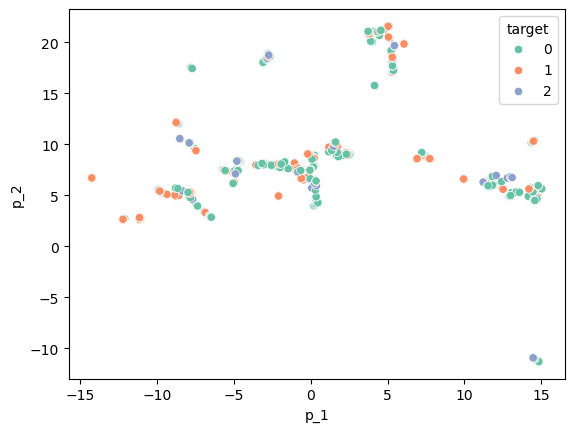

In [30]:
df_values = df_embedding.drop(columns=["target", "experimental_characteristics"])
nonlinear_instance = NonLinearReductions(dataset=df_values)

transform_values_umap = nonlinear_instance.applyUMAP()
transform_values_umap["target"] = df_embedding["target"].values

sns.scatterplot(data=transform_values_umap, x="p_1", y="p_2", hue="target", palette="Set2")
